## Introduction
The purpose of this notebook to get the basic understanding of handle dataset, performing EDA, visualization of data and how different classification model works for the same data. I will be dealing with Iris dataset which is well-known to compare three models Logistic Regression, KNN and Decision Trees.
##### **Problem Statement**: Build classification model to classify Iris flowers categories 'Setosa' , 'Virginica' and Versicolor.
##### **Dataset Description**: The dataset has four main features (SepalLenght, SepalWidth, PetalLenght, PetalWidth) and an Id column (which we will be dropping).
##### **Purpose of this Notebook** : This notebook will give you an overview of basic level comparison of different classification models and how to work with data.
##### **Models we will be comparing**: Logistics Regression, Decision Trees, KNN

In [1]:
## All the important libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,f1_score,confusion_matrix,ConfusionMatrixDisplay
##random seed
np.random.seed(42)

In [2]:
#loaded dataset
df = pd.read_csv("data/Iris.csv")
df = df.drop(columns="Id").copy()
print(f"1- Shape of the dataset after dropping ID column {df.shape}\n")
print(f"2- First 10 rows of the dataset:\n {df.head(10)}")

1- Shape of the dataset after dropping ID column (150, 5)

2- First 10 rows of the dataset:
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa
5            5.4           3.9            1.7           0.4  Iris-setosa
6            4.6           3.4            1.4           0.3  Iris-setosa
7            5.0           3.4            1.5           0.2  Iris-setosa
8            4.4           2.9            1.4           0.2  Iris-setosa
9            4.9           3.1            1.5           0.1  Iris-setosa


In [3]:
#datatypes of every column
print(f"Data types of our columns: \n{df.dtypes}")

Data types of our columns: 
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object


In [4]:
#checkin for null values in every columns
print(f"Sum of Null values in our dataset: \n{df.isnull().sum()}")

Sum of Null values in our dataset: 
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


### **EDA**
In this section we will be working on EDA (Exploratory Data Analysis) which will give us insights on the data i.e., which columns to keep, how much data fluctuates, how data is distributed across classes etc. We will be working with different types of plots to see patterns in the data.

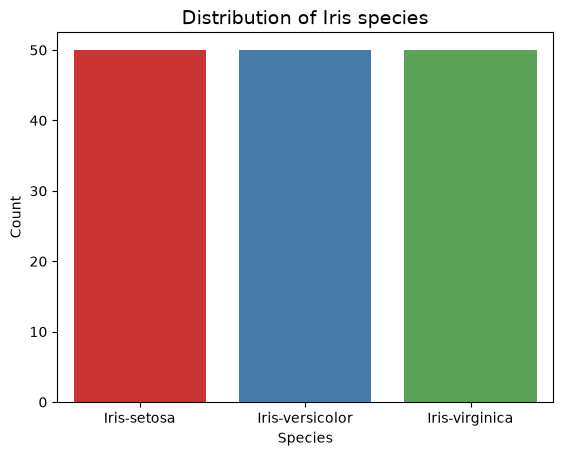

In [5]:
sns.countplot(data=df,x=df['Species'],hue=df['Species'],palette="Set1")
plt.title("Distribution of Iris species",fontsize=14)
plt.ylabel("Count")
plt.xlabel("Species")
plt.show()

In [41]:
df.groupby(df["Species"].where(df['Species']== 'Iris-setosa'))['SepalLengthCm'].describe()

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Iris-setosa,50.0,5.006,0.35249,4.3,4.8,5.0,5.2,5.8


### BOX PLOT 

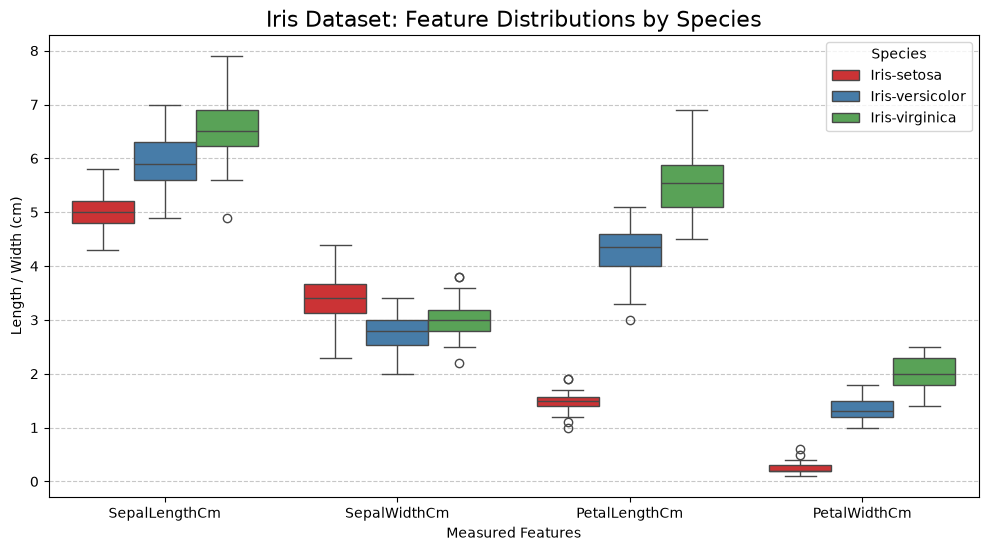

In [7]:

df_melted = df.melt(id_vars="Species",var_name="Features",value_name="cm")
plt.figure(figsize=(12,6))
sns.boxplot(data=df_melted,x="Features",y="cm",hue="Species",palette="Set1")
plt.title('Iris Dataset: Feature Distributions by Species', fontsize=16)
plt.xlabel('Measured Features')
plt.ylabel('Length / Width (cm)')
plt.legend(title='Species')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### SCATTER PLOT

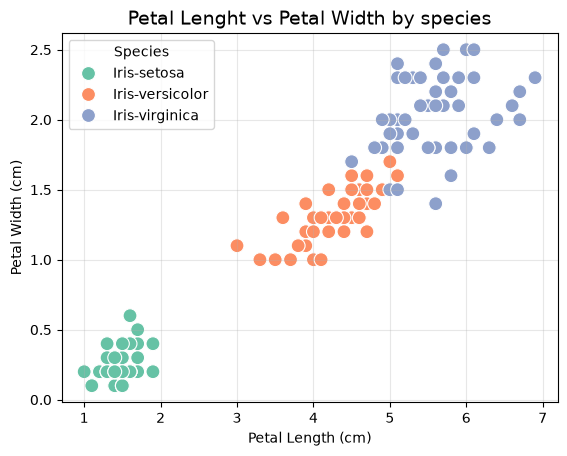

In [8]:
#Scatter plot
sns.scatterplot(data=df,x=df["PetalLengthCm"],y=df["PetalWidthCm"],hue="Species",palette="Set2",s=100)
plt.title("Petal Lenght vs Petal Width by species",fontsize=14)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.grid(alpha=0.3)
plt.show()

### PAIR PLOT

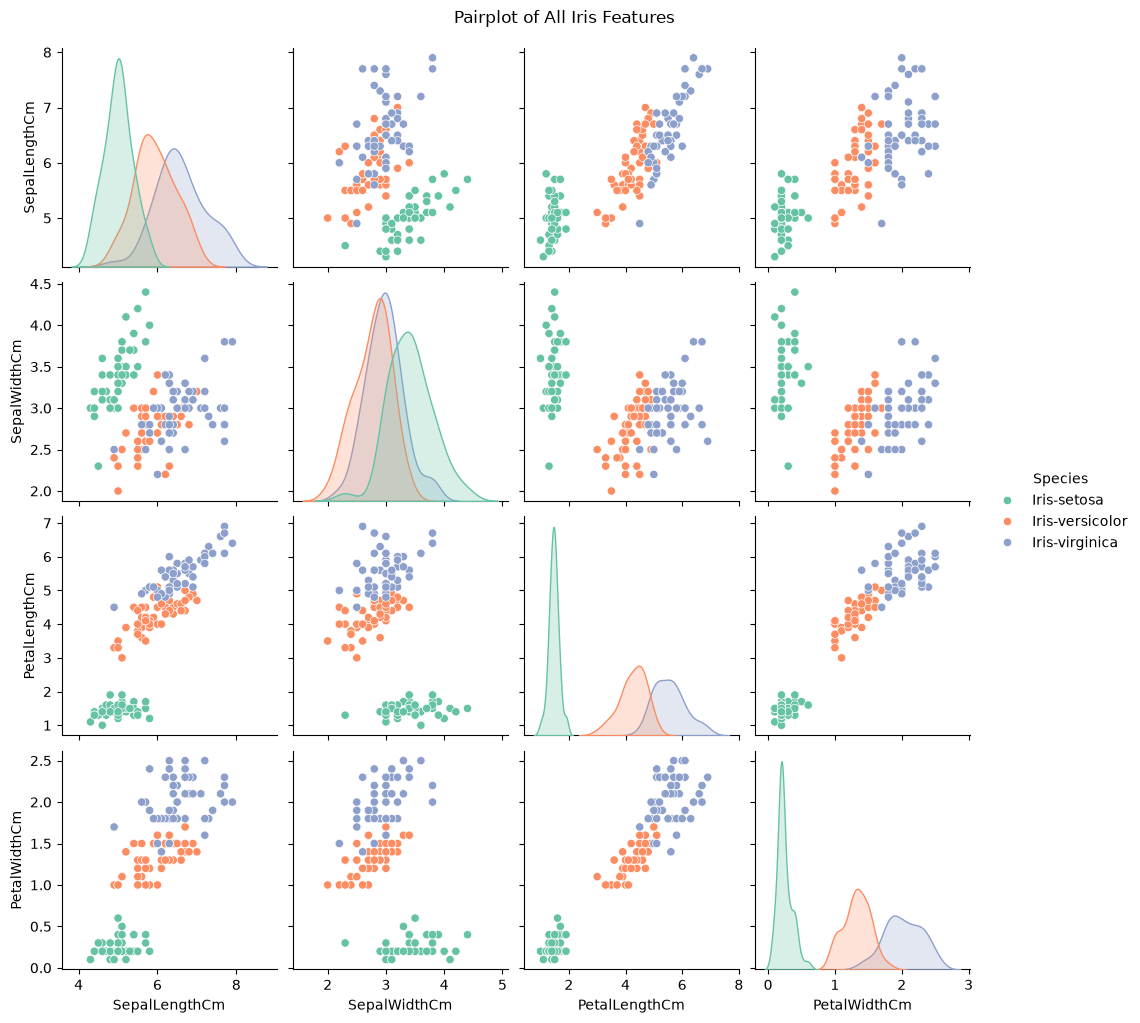

In [9]:
#pair plot
sns.pairplot(data=df,hue="Species",palette="Set2",diag_kind='kde')
plt.suptitle('Pairplot of All Iris Features', y=1.02) 
plt.show()

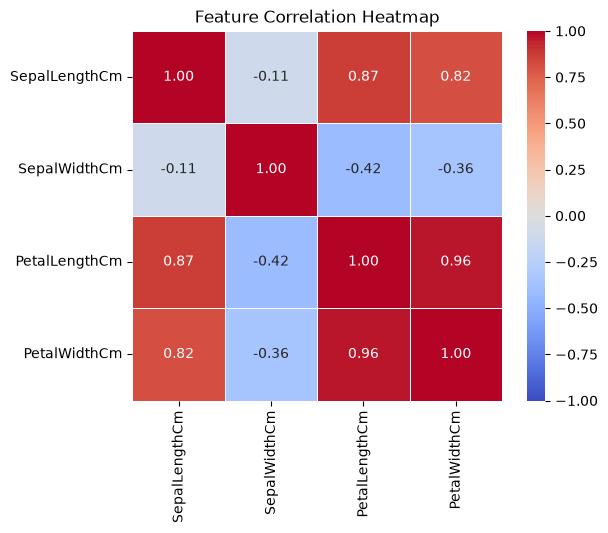

In [10]:
numerical_df = df.drop('Species',axis=1)
correlation_matrix = numerical_df.corr() # correlation matrix
sns.heatmap(data=correlation_matrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
            square=True,
            fmt='.2f',
            vmin=-1,vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

## EDA Summary: 
By performing EDA on the dataset, it is clear that "Setosa" is clearly distinguishable from the other two because of it's small size of petal lenght and width for better understanding look at the scatter plot you'll find setosa in a corner while the other two are closer to each other and there is a strong correlation between petal width and petal lenght, as one increase other one also increase. Based on that conclusion, we can drop one of them. In my suggestion it would be wise to drop petal width but for educational purposes I am not dropping anything.

### FEATURE SELECTION, TRAIN, TEST AND SPLIT

In [11]:
#feature and label selection
X = df.drop(columns='Species')
y = df["Species"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f"X_train lenght: {len(X_train)}\nX_test lenght: {len(X_test)}\ny_train lenght: {len(y_train)}\ny_test lenght: {len(y_test)}")

X_train lenght: 120
X_test lenght: 30
y_train lenght: 120
y_test lenght: 30


### ENCODING OF LABELS
Encoding of labels mean converting our String classes in to number like 0,1,2. 

In [12]:
le = LabelEncoder()
y_train_encode = le.fit_transform(y_train)
y_test_encode = le.transform(y_test)
y_encoded = le.fit_transform(y) # whole y encoded because of cross-validation process

### SCALING 

In [13]:
#scaling 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### TRAINING AND MODEL SELECTION (LOGISTIC REGRESSION)

In [14]:
LRmodel = LogisticRegression()
LRmodel.fit(X_train_scaled,y_train_encode)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [15]:
y_pred = LRmodel.predict(X_test_scaled)

#### Accuracy of logistic regression model

In [16]:
print(f"Accuracy of LR: {LRmodel.score(X_test_scaled,y_test_encode):.4f}")


Accuracy of LR: 0.9333


#### Cross Validation

In [17]:
pipeline = Pipeline([('scaler',StandardScaler()),
                     ('Lr',LogisticRegression())])

scores = cross_val_score(pipeline,X,y_encoded,cv=5,scoring='accuracy')
# print(f"The accuracy score of cross-validation (5): {scores}")
print(f"Logistic Regression Mean cross-validation Score: {scores.mean():.4f}")

Logistic Regression Mean cross-validation Score: 0.9600


### Confusion matrix

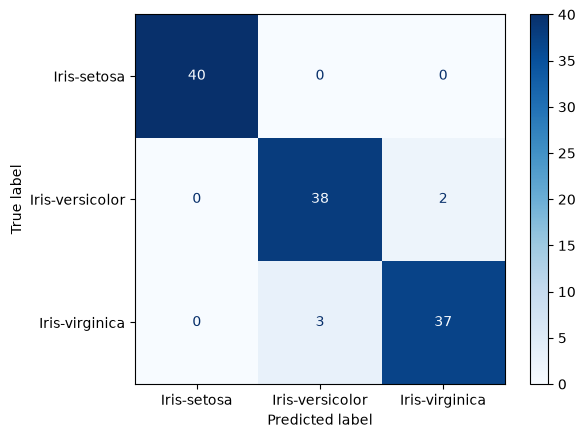

In [18]:
ConfusionMatrixDisplay.from_estimator(LRmodel,
                                      X_train_scaled,
                                      y_train_encode,
                                      cmap='Blues',
                                      display_labels=le.classes_)
plt.show()

### Coefficients Inspection

In [19]:
cofc = LRmodel.coef_
intercept = LRmodel.intercept_
feature_names = X.columns
class_names = le.classes_
coef_df = pd.DataFrame(cofc,columns=feature_names,index=class_names)
coef_df['Intercept'] = intercept
# print(coef_df.round(4))
coef_df.round(4)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Intercept
Iris-setosa,-1.0918,1.0203,-1.7976,-1.6952,-0.3127
Iris-versicolor,0.5389,-0.3595,-0.2079,-0.8007,1.9105
Iris-virginica,0.5529,-0.6608,2.0055,2.4959,-1.5978


### TRAINING AND MODEL SELECTION (KNN)

In [20]:
# KNN with 3 neighbors to look at
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train_scaled,y_train_encode)

y_pred3 = knn3.predict(X_test_scaled)
#Accuracy Score
print(f"Accuracy with n_neighbors = 3 : {knn3.score(X_test_scaled,y_test_encode):.4f}")
#converting predicted class to string
# le.inverse_transform([y_pred3[10]])[0]

Accuracy with n_neighbors = 3 : 0.9333


#### cross-validation for n = 3 neighbors

In [21]:
pipeline = Pipeline([('scaler',StandardScaler()),
                     ('knn',KNeighborsClassifier(n_neighbors=3))])

scores = cross_val_score(pipeline,X,y_encoded,cv=5,scoring='accuracy')
# print(f"The accuracy score of cross-validation (5): {scores}")
print(f"Mean Score: {scores.mean():.4f}")

Mean Score: 0.9533


#### knn with 5 neighbors

In [22]:
#knn with 5 neighbors
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_scaled,y_train_encode)
y_pred5 = knn5.predict(X_test_scaled)
print(f"Accuracy with n_neighbors = 5 : {knn5.score(X_test_scaled,y_test_encode):.4f}")
# le.inverse_transform([y_pred5[10]])[0]

Accuracy with n_neighbors = 5 : 0.9333


#### cross-validation for n = 5 neighbors

In [23]:
pipeline = Pipeline([('scaler',StandardScaler()),
                     ('knn',KNeighborsClassifier(n_neighbors=5))])

scores = cross_val_score(pipeline,X,y_encoded,cv=5,scoring='accuracy')
# print(f"The accuracy score of cross-validation (5): {scores}")
print(f"KNN (n=5) cross-validation Mean Score: {scores.mean():.4f}")

KNN (n=5) cross-validation Mean Score: 0.9600


#### Classification report

In [24]:
print(classification_report(y_test_encode,y_pred5,target_names=le.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



#### Confusion matrix

In [25]:
#text based confusion-matrix
confusion_matrix(y_test_encode,y_pred5)

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  2,  8]])

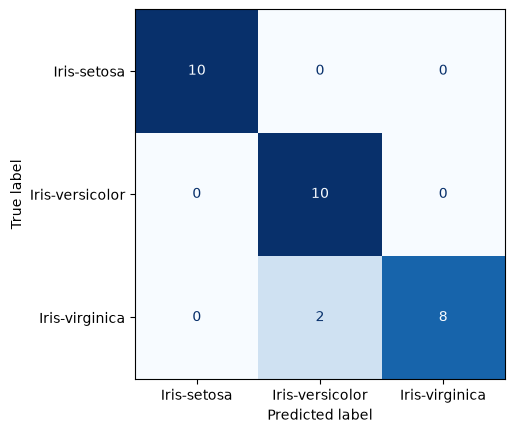

In [26]:
cmd = ConfusionMatrixDisplay.from_estimator(knn5,
                                            X_test_scaled,
                                            y_test_encode,
                                            cmap="Blues",
                                            colorbar=False,
                                            display_labels=le.classes_)
plt.show()

#### cross-validation for n = 7 neighbors

In [27]:
pipeline = Pipeline([('scaler',StandardScaler()),
                     ('knn',KNeighborsClassifier(n_neighbors=7))])

scores = cross_val_score(pipeline,X,y_encoded,cv=5,scoring='accuracy')
# print(f"The accuracy score of cross-validation (5): {scores}")
print(f"Mean Score: {scores.mean():.4f}")

Mean Score: 0.9600


#### knn with 11 neighbors

In [28]:
#knn with 11 neighbors
knn11 = KNeighborsClassifier(n_neighbors=11)
knn11.fit(X_train_scaled,y_train_encode)
y_pred11 = knn11.predict(X_test_scaled)
print(f"Accuracy with n_neighbors = 11 : {knn11.score(X_test_scaled,y_test_encode):.4f}")
# le.inverse_transform([y_pred11[10]])[0]

Accuracy with n_neighbors = 11 : 0.9667


#### cross-validation for n = 11 neighbors

In [29]:
pipeline = Pipeline([('scaler',StandardScaler()),
                     ('knn',KNeighborsClassifier(n_neighbors=11))])

scores = cross_val_score(pipeline,X,y_encoded,cv=5,scoring='accuracy')
# print(f"The accuracy score of cross-validation (5): {scores}")
print(f"Mean Score: {scores.mean():.4f}")

Mean Score: 0.9467


### Visual Plot for KNN values (n= 1 to 15)

In [30]:
k_values = range(1,16)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors= k)

    knn.fit(X_train_scaled,y_train_encode)
    k_score = knn.score(X_test_scaled,y_test_encode)
    accuracies.append(k_score)
best_index = np.argmax(accuracies)
best_k = k_values[best_index]
best_accuracy = accuracies[best_index]
print(f"The best K is {best_k} with an accuracy of {best_accuracy:.4f}") # the simple accuracy for simple split. It might be different for cross-validation.

The best K is 1 with an accuracy of 0.9667


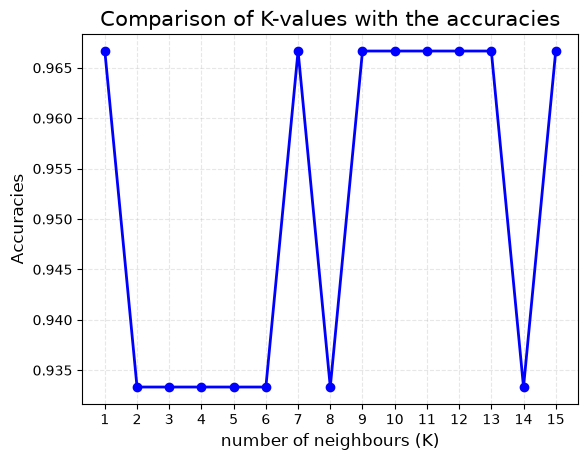

In [31]:
plt.plot(k_values,accuracies,marker="o",linestyle='-',color='blue',linewidth=2)
plt.title("Comparison of K-values with the accuracies",fontsize=15)
plt.xlabel("number of neighbours (K)",fontsize=12)
plt.ylabel("Accuracies",fontsize=12)
plt.xticks(k_values)
plt.grid(True,alpha=0.3,linestyle = '--')
# plt.legend()
plt.show()


### Decision Tree

In [32]:
DTmodel = DecisionTreeClassifier(max_depth=3)
DTmodel.fit(X_train,y_train_encode)
ydt_pred = DTmodel.predict(X_test)
print(f"Decision Tree Accuracy Score: {DTmodel.score(X_test,y_test_encode):.4f}")

Decision Tree Accuracy Score: 0.9667


#### cross validation for decision tree

In [33]:
score = cross_val_score(DTmodel,X,y_encoded,cv=5)
print(f"Decision Tree (max_depth=3) Mean cross-validation Score: {score.mean():.4f}")
# print(f"Standard deviation: {score.std():.4f}")

Decision Tree (max_depth=3) Mean cross-validation Score: 0.9733


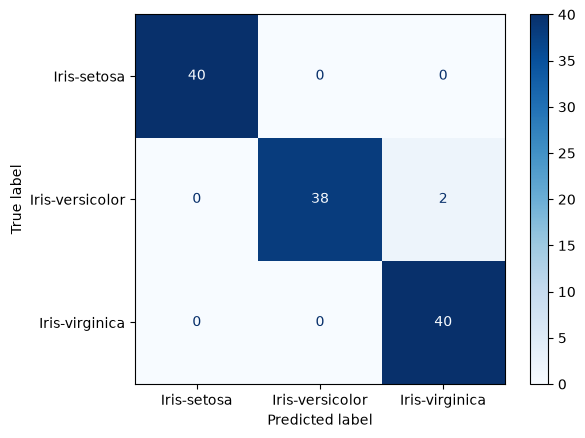

In [34]:
ConfusionMatrixDisplay.from_estimator(DTmodel,X_train,y_train_encode,display_labels=le.classes_,cmap='Blues')
plt.show()

### Tree Rules

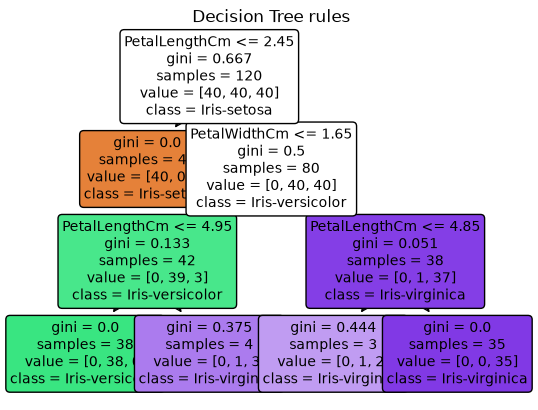

In [35]:
from sklearn.tree import plot_tree
plot_tree(DTmodel,
          feature_names=X_train.columns,
          class_names=le.classes_,
          filled=True,
          rounded=True,
          fontsize=10
          )
plt.title("Decision Tree rules")
plt.show()

## Test and CV comparison

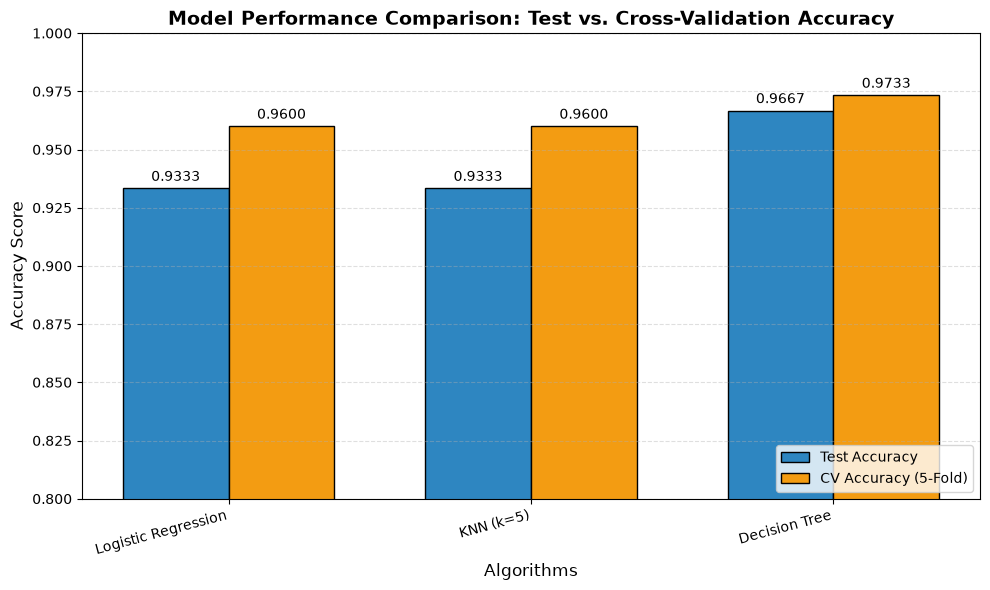

In [36]:
scores = {
    'Logistic Regression': {
        'Test Accuracy': 0.9333,  
        'CV Accuracy': 0.9600     
    },
    'KNN (k=5)': {
        'Test Accuracy': 0.9333,  
        'CV Accuracy': 0.9600     
    },
    'Decision Tree': {
        'Test Accuracy': 0.9667,  
        'CV Accuracy': 0.9733    
    }
}

models = list(scores.keys())
test_scores = [scores[model]['Test Accuracy'] for model in models]
cv_scores = [scores[model]['CV Accuracy'] for model in models]


x = np.arange(len(models))  # The label locations (e.g., [0, 1, 2])
width = 0.35  # The width of the bars

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Test Accuracy bars (left side of each group)
bars1 = ax.bar(x - width/2, test_scores, width, label='Test Accuracy', color='#2E86C1', edgecolor='black')

# Plot CV Accuracy bars (right side of each group)
bars2 = ax.bar(x + width/2, cv_scores, width, label='CV Accuracy (5-Fold)', color='#F39C12', edgecolor='black')

# 4. Add labels, title, and custom x-axis tick marks
ax.set_xlabel('Algorithms', fontsize=12)
ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_title('Model Performance Comparison: Test vs. Cross-Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')  # Slight rotation if names are long
ax.legend(loc='lower right')

# 5. Add the numerical values ON TOP of the bars
ax.bar_label(bars1, fmt='%.4f', padding=3)  
ax.bar_label(bars2, fmt='%.4f', padding=3)

# 6. Set y-axis limits
ax.set_ylim(0.8, 1.0)

# Add a horizontal line for perfect score
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## **Conclusion**
By doing all this comparison, EDA, plotting the best model that performed better on this iris dataset is Desicision Trees with the CV score of 0.97 (97%). I know that logistic regression would also perform better if had done some better feature engineering on features. But this is my conclusion Decision Trees with the max_depth of 3. Every model has it's limitations such as KNNs can give better result at neighbours > 1, preventinG from overfittinG, Decision trees would overfit if depth is so large, logistic regression can perform better on non-messy data. Every model has it's pros and cons.

In [ ]:
# import joblib
# joblib.dump(LRmodel,"lr_model.pkl")
# joblib.dump(knn5,"knn_model.pkl")
# joblib.dump(DTmodel,'dt_model.pkl')
# joblib.dump(scaler,'scaler.pkl')
# joblib.dump(le,'label_encoder.pkl')

['label_encoder.pkl']